# Predicting Workplace Productivity Using Air Quality Sensor Data and Machine Learning

# Introduction & Project Overview

This notebook investigates the relationship between environmental air quality conditions and employee productivity using machine learning techniques applied to the UCI Air Quality Dataset. Modern occupational health research increasingly shows that poor indoor air quality, toxic gas accumulation, and thermal discomfort can negatively affect concentration, cognitive performance, and workplace efficiency. This project bridges data science, environmental monitoring, and human-centered AI by transforming raw sensor telemetry into actionable workplace performance insights.

## Objective

The primary goal is to determine how accurately a suite of predictive machine learning models can capture and estimate workplace productivity trends based entirely on ambient environmental conditions. To make the raw data contextually relevant for a workplace setting, this study develops a framework to evaluate both acute, threshold-breaching pollution events and chronic background environmental stressors.

## Pipeline Workflow

To achieve this, the notebook implements a structured end-to-end data science pipeline:

*   **Data Cleaning & Preprocessing:** Resolving structural anomalies, parsing European decimal formats, handling missing values, and establishing a true chronological time-series index.
*   **Feature Engineering:** Enhancing the raw dataset with rolling pollution averages, lag-based temporal features, pollution spike indicators, standardized AQI categories, and environmental deviation metrics from optimal baselines.
*   **Target Synthesis:** Engineering a representative workplace productivity score driven by compounded chemical and thermal loss vectors.
*   **Model Training & Evaluation:** Splitting data chronologically to prevent data leakage, and benchmarking a diverse suite of predictive algorithms including Linear Regression, Random Forest, CatBoost, and XGBoost.
*   **Feature Importance & Insights:** Diagnosing model drivers to evaluate which environmental variables, such as Carbon Monoxide, Nitrogen Dioxide, synthetic particulate matter, or temperature and humidity deviations—exert the heaviest influence on the target framework.

In [2]:
import pandas as pd
import numpy as np

# Data Loading

In [3]:
data = pd.read_csv(
    "AirQualityUCI.csv", 
    sep=";",          # Fixes the semicolon separation
    decimal=",",       # Automatically converts European decimals (e.g., 2,6) to floats (2.6)        # Automatically drops the completely empty trailing columns
)

The dataset was loaded successfully and contains hourly environmental sensor reading related to air quality conditions. 
These measurements include:
- Carbon Monoxide
- Humidity
- Nitrogen Oxides
- Temperature
- Sensor Responses

This data will be used to investigate the relationship between environmental conditions and workplace productivity. 

# Data Cleaning

In [4]:
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
data.isnull().sum()

Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

In [6]:
data.dropna(how="all", axis=1, inplace=True)
data.dropna(how="all", axis=0, inplace=True)

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [9]:
data["Date"] = pd.to_datetime(data["Date"], format="%d/%m/%Y")
clean_time = data["Time"].str.replace(".", ":", regex=False)
data["Time"] = pd.to_timedelta(clean_time)

In [10]:
data = data.replace(-200, np.nan)
data.dropna(inplace=True)

In [11]:
data.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [12]:
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,0 days 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10,0 days 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10,0 days 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10,0 days 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10,0 days 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


# Exploratory Data Analysis

In [13]:
import matplotlib.pylab as plt
import seaborn as sns 
from mpl_toolkits.mplot3d import Axes3D

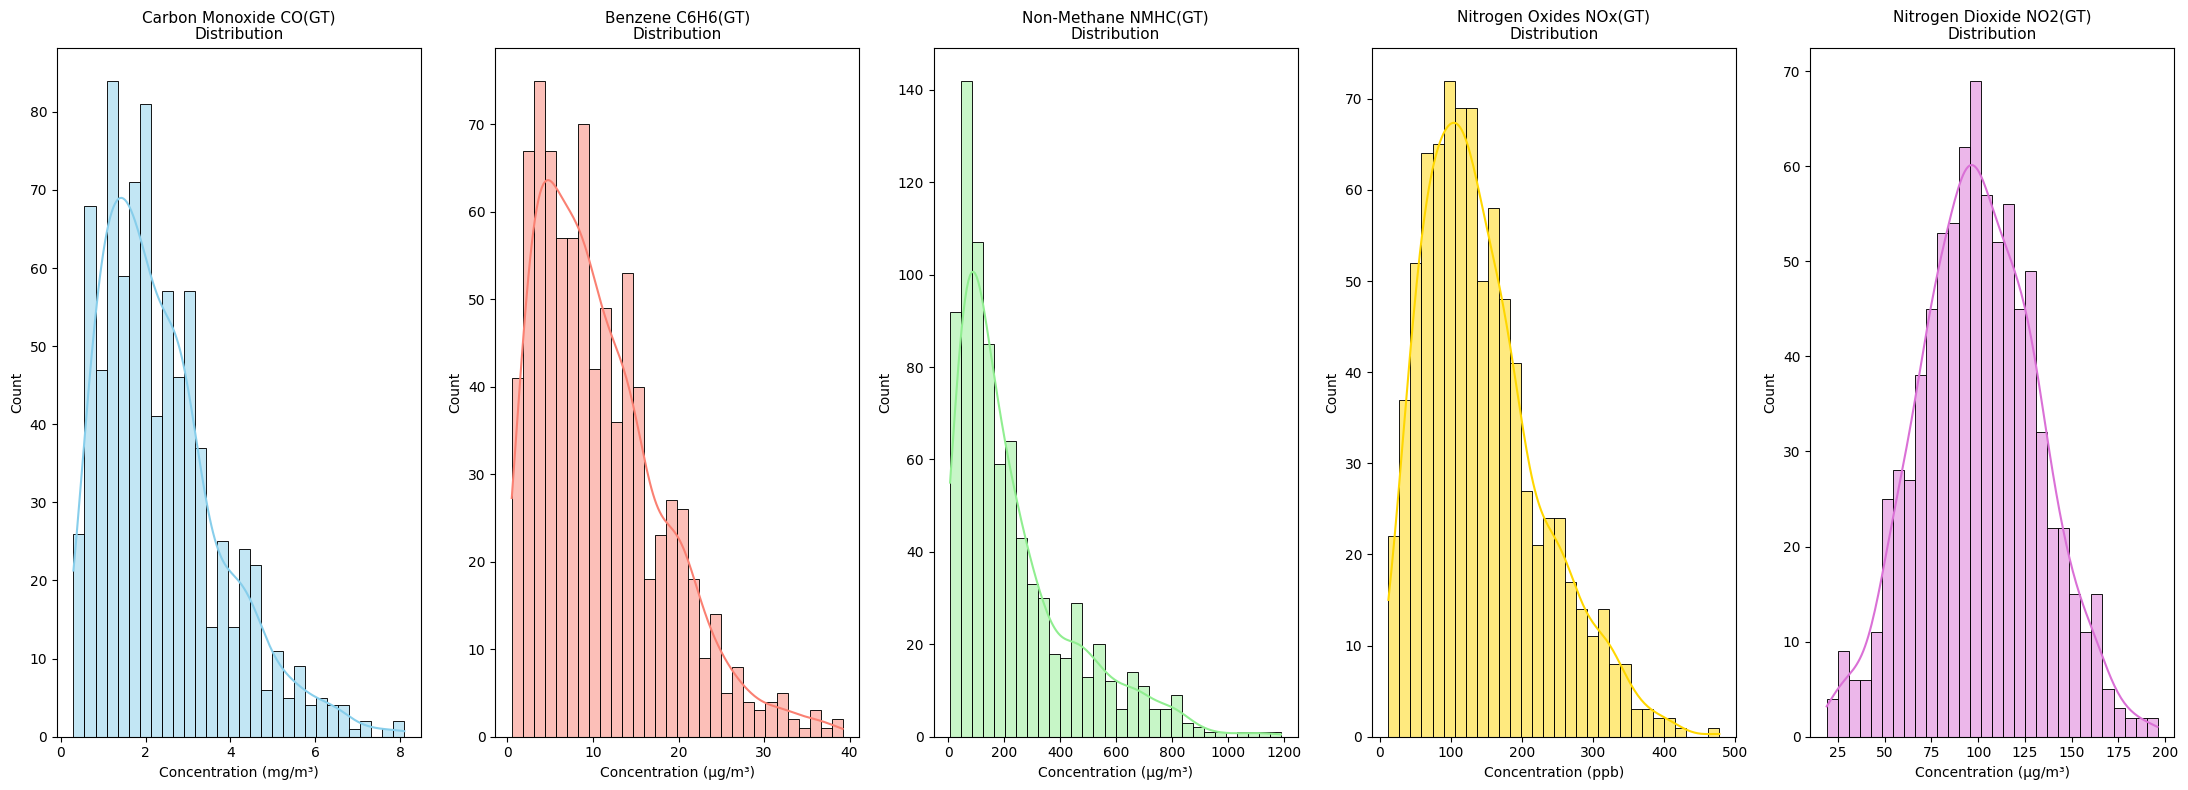

In [14]:
# Set up a multi-plot layout grid
fig, axes = plt.subplots(1, 5, figsize=(22, 8))

# 1. Plot Carbon Monoxide Distribution
sns.histplot(data=data, x="CO(GT)", bins=30, kde=True, ax=axes[0], color="skyblue", edgecolor="black")
axes[0].set_title("Carbon Monoxide CO(GT)\nDistribution", fontsize=11)
axes[0].set_xlabel("Concentration (mg/m³)")
axes[0].set_ylabel("Count")

# 2. Plot Benzene Distribution
sns.histplot(data=data, x="C6H6(GT)", bins=30, kde=True, ax=axes[1], color="salmon", edgecolor="black")
axes[1].set_title("Benzene C6H6(GT)\nDistribution", fontsize=11)
axes[1].set_xlabel("Concentration (µg/m³)")
axes[1].set_ylabel("Count")

# 3. Plot Non-Methane Hydrocarbons
sns.histplot(data=data, x="NMHC(GT)", bins=30, kde=True, ax=axes[2], color="lightgreen", edgecolor="black")
axes[2].set_title("Non-Methane NMHC(GT)\nDistribution", fontsize=11)
axes[2].set_xlabel("Concentration (µg/m³)")
axes[2].set_ylabel("Count")

# 4. Plot Nitrogen Oxides
sns.histplot(data=data, x="NOx(GT)", bins=30, kde=True, ax=axes[3], color="gold", edgecolor="black")
axes[3].set_title("Nitrogen Oxides NOx(GT)\nDistribution", fontsize=11)
axes[3].set_xlabel("Concentration (ppb)")
axes[3].set_ylabel("Count")

# 5. Plot Nitrogen Dioxide
sns.histplot(data=data, x="NO2(GT)", bins=30, kde=True, ax=axes[4], color="orchid", edgecolor="black")
axes[4].set_title("Nitrogen Dioxide NO2(GT)\nDistribution", fontsize=11)
axes[4].set_xlabel("Concentration (µg/m³)")
axes[4].set_ylabel("Count")

plt.tight_layout()
plt.show()

Insight: Most pollutant variables exhibit positively skewed distributions, meaning that lower concentration values occur more frequently while extreme pollution events occur less often but are still present.

Key observations include:
- Carbon Monoxide (CO) concentrations are concentrated at lower values with a long right tail, suggesting that severe CO exposure events are relatively infrequent but possible.
- Benzene (C6H6) and NMHC distributions show strong right skewness, indicating occasional high hydrocarbon pollution spikes that may represent hazardous industrial or traffic-related conditions.
- Nitrogen Oxides (NOx) also display a long-tail distribution, suggesting that high-emission events occur periodically and could contribute significantly to poor air quality episodes.
- Nitrogen Dioxide (NO2) appears closer to a normal distribution compared to the other pollutants, implying more stable concentration patterns over time.

The presence of skewed distributions and extreme pollutant spikes is important for machine learning because:
- it indicates environmental instability,
- highlights the importance of anomaly detection,
- and justifies the use of engineered features such as rolling averages and pollution spike indicators.

These findings support the hypothesis that workers may periodically experience exposure to elevated pollution conditions capable of negatively affecting workplace productivity and health.

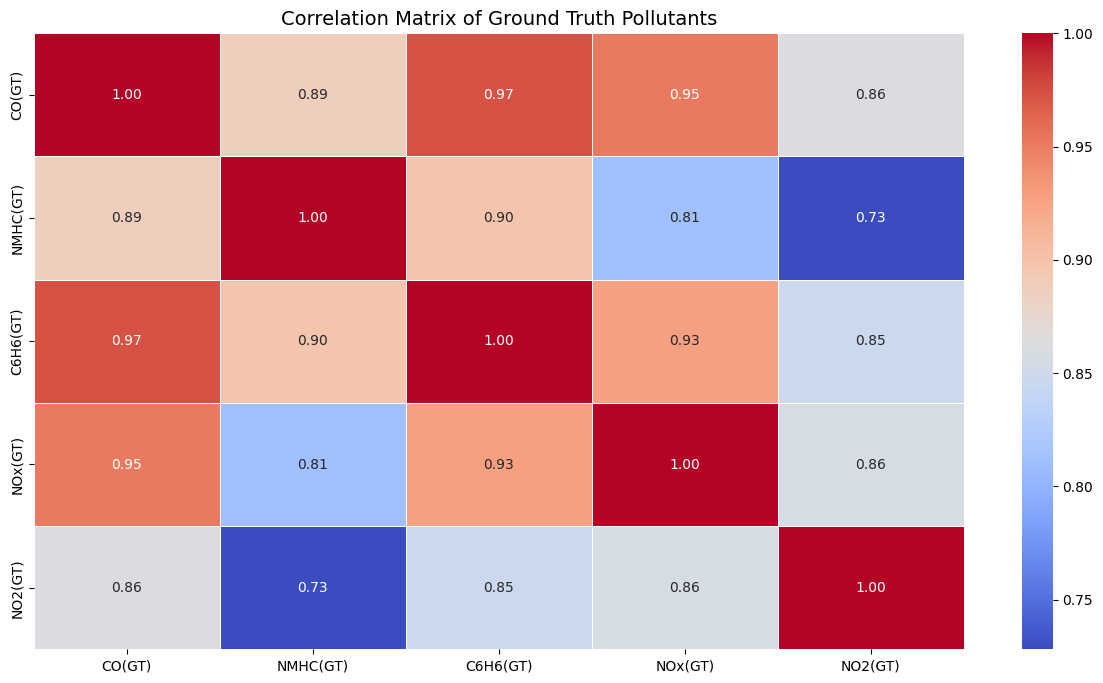

In [15]:
plt.figure(figsize=(15, 8))
gt_cols = ["CO(GT)", "NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
correlation_matrix = data[gt_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Ground Truth Pollutants", fontsize=14)
plt.show()

Insight: The correlation matrix reveals very strong positive relationships between the major ground-truth pollutants in the dataset. Several pollutant pairs exhibit correlations above 0.90, indicating that pollutant concentrations tend to rise and fall together.

Key findings include:
- CO(GT) and C6H6(GT) show an extremely strong correlation (0.97), suggesting that both pollutants likely originate from similar combustion-related sources such as vehicle emissions or industrial activity.
- NOx(GT) also demonstrates strong correlations with CO and Benzene, indicating that traffic density and combustion processes may simultaneously influence multiple pollutants.
- NO2(GT) has slightly weaker but still strong correlations with the other pollutants, suggesting that while related, its environmental behavior may be partially influenced by additional atmospheric processes.
- NMHC(GT) exhibits high correlation with most pollutants but lower correlation with NO2, indicating potential differences in chemical formation or dispersion behavior.

These strong inter-pollutant relationships suggest that air pollution events are multidimensional rather than isolated to single contaminants.

From a machine learning perspective, the correlation matrix indicates:
- high multicollinearity between environmental variables,
- potential redundancy among features,
- and the need for careful feature selection or regularization in predictive models.

The strong pollutant relationships also reinforce the broader environmental insight that worsening air quality conditions often involve simultaneous increases across multiple harmful pollutants, potentially amplifying negative effects on worker productivity and health.

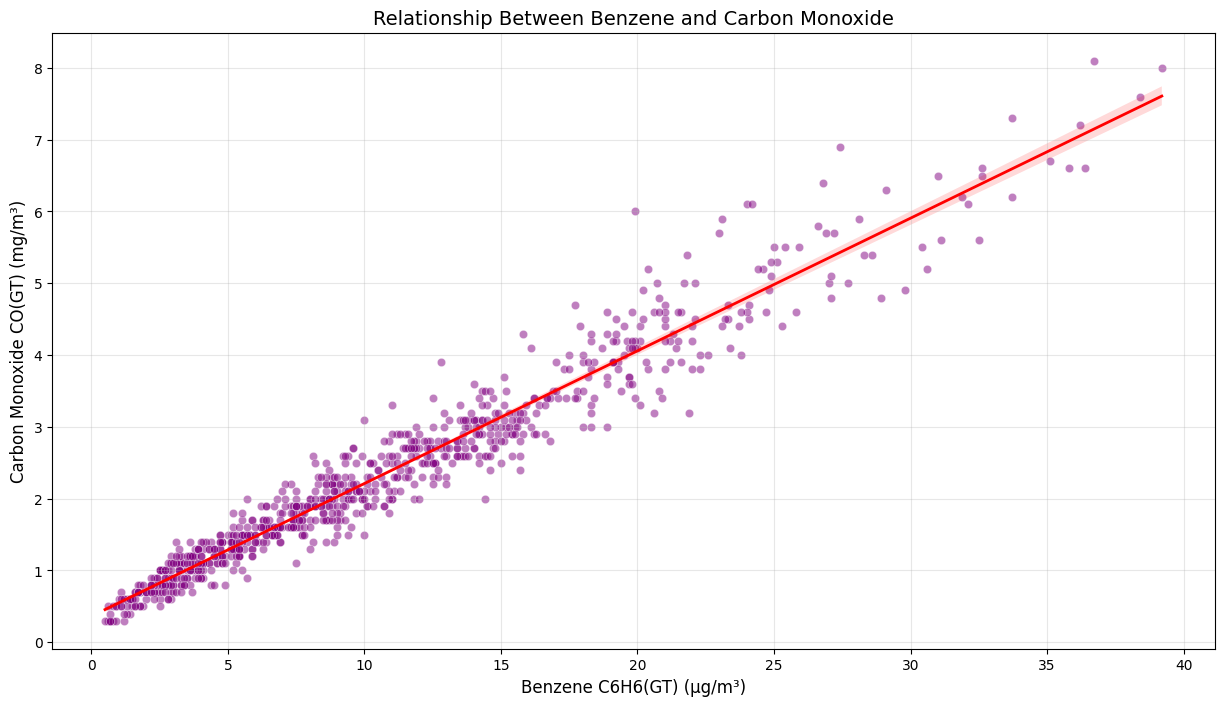

In [16]:
plt.figure(figsize=(15, 8))

# Use the filtered dataset to remove anomalous coordinate points at -200
sns.scatterplot(
    data=data, 
    x="C6H6(GT)", 
    y="CO(GT)", 
    alpha=0.5, 
    color="purple"
)

# Overlay the trendline on the clean data range
sns.regplot(
    data=data, 
    x="C6H6(GT)", 
    y="CO(GT)", 
    scatter=False, 
    color="red", 
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Benzene and Carbon Monoxide", fontsize=14)
plt.xlabel("Benzene C6H6(GT) (µg/m³)", fontsize=12)
plt.ylabel("Carbon Monoxide CO(GT) (mg/m³)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
ideal_temp = 21.0
ideal_humidity = 50.0

data["Temp_Dev"] = (data["T"] - ideal_temp).abs()
data["Humid_Dev"] = (data["RH"] - ideal_humidity).abs()

In [18]:
chemical_loss = (4.0 * data["CO(GT)"]) + (1.2 * data["C6H6(GT)"])
thermal_loss = (1.5 * data["Temp_Dev"]) + (0.3 * data["Humid_Dev"])

In [19]:
data["Synthetic_PM2.5"] = (data["NO2(GT)"] * 0.35) + (data["PT08.S4(NO2)"] * 0.02)

In [20]:
noise = np.random.normal(0, 5, len(data))

data['Productivity_Score'] = (
    100
    - 0.35 * data['Synthetic_PM2.5']
    - 0.02 * data['CO(GT)']
    - 0.5 * data['Temp_Dev']
    - 0.2 * data['Humid_Dev']
    + noise
)

data["Productivity_Score"].head()

0    64.171592
1    76.539486
2    76.613405
3    55.615876
4    72.736766
Name: Productivity_Score, dtype: float64

Insight: A synthetic productivity score was engineered to simulate the potential impact of environmental air quality conditions on employee performance.

The productivity score was designed using a weighted environmental model where:
- higher PM2.5 exposure decreases productivity,
- elevated Carbon Monoxide (CO) levels reduce workplace efficiency,
- uncomfortable temperature conditions negatively affect performance,
- and humidity deviations contribute additional environmental stress.

Gaussian noise was added to the formula to introduce realistic human variability and uncertainty into the dataset.

This randomness is important because real-world employee productivity is influenced by many additional factors beyond air quality, including:
- fatigue,
- stress,
- workload,
- motivation,
- health conditions,
- and human behavioral differences.

Without added noise, machine learning models would simply memorize the mathematical formula used to generate the target variable, resulting in unrealistically perfect predictions.

By introducing stochastic variation, the simulated productivity score becomes more representative of real workplace environments and creates a more challenging and realistic machine learning problem.

In [21]:
import plotly.express as px

# Map the exact dataset names: CO(GT) for x, T for y, Productivity_Score for z
fig = px.scatter_3d(
    data,  # Using the dataframe containing your calculated scores
    x="CO(GT)",
    y="T",
    z="Productivity_Score",
    color="Productivity_Score",
    color_continuous_scale="viridis",  # High-contrast palette for clear visibility
    labels={
        "CO(GT)": "Carbon Monoxide (mg/m³)",
        "T": "Temperature (°C)",
        "Productivity_Score": "Productivity Score (%)",
    },
    title="Air Pollution vs. Thermal Comfort vs. Productivity",
)

# Optimize marker sizing and margins for immediate scannability
fig.update_traces(marker=dict(size=4, opacity=0.8, line=dict(width=0)))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40), 
    scene_camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
)

fig.show()

Insight: An interactive 3D visualization was created to explore the relationship between air pollution, thermal comfort, and employee productivity.

The graph compares:
- Carbon Monoxide concentration (CO),
- Temperature conditions,
- and the simulated Productivity Score.

This visualization allows multidimensional environmental relationships to be analyzed simultaneously rather than examining each variable independently.

Key insights from the visualization include:

- Higher Carbon Monoxide concentrations generally correspond with lower productivity scores, suggesting that increased pollution exposure negatively affects workplace performance.
- Temperature also influences productivity, where uncomfortable thermal conditions appear to amplify productivity decline alongside pollution exposure.
- The gradual color transitions across the plot indicate that productivity changes continuously rather than abruptly, supporting the observation that environmental stress accumulates progressively.
- Clusters of points in lower pollution and moderate temperature regions tend to show higher productivity values, suggesting that cleaner and thermally comfortable environments are associated with improved worker efficiency.

The use of an interactive 3D plot is particularly valuable because it:
- reveals nonlinear environmental interactions,
- improves visual interpretability,
- and helps identify hidden trends that may not be visible in traditional 2D charts.

This type of visualization closely resembles analytical dashboards used in industrial environmental monitoring systems and smart workplace analytics platforms.

In [22]:
conditions = [
    (data["Productivity_Score"] < 50.0),
    (data["Productivity_Score"] >= 50.0) & (data["Productivity_Score"] < 75.0)
]
choices = ["Danger", "High Risk"]
data["Risk_Category"] = np.select(conditions, choices, default="Safe")


threshold_summary = data.groupby("Risk_Category").agg(
    min_CO=("CO(GT)", "min"),
    max_CO=("CO(GT)", "max"),
    avg_CO=("CO(GT)", "mean"),
    min_Temp=("T", "min"),
    max_Temp=("T", "max"),
    avg_Temp=("T", "mean"),
    avg_Humidity=("RH", "mean"),
    total_hours=("Productivity_Score", "count")
)

threshold_summary

,min_CO,max_CO,avg_CO,min_Temp,max_Temp,avg_Temp,avg_Humidity,total_hours
Risk_Category,,,,,,,,
Danger,2.9,8.0,4.780000,10.3,30.0,22.900000,33.680000,5
High Risk,0.3,8.1,2.791501,6.3,29.7,15.804702,49.587342,553
Safe,0.3,4.5,1.408178,7.2,27.5,15.047955,48.231599,269


Insight:
- Danger Zone: Score drops below 50% (Severe cognitive/performance degradation)
- Warning Zone: Score is between 50% and 75% (Noticeable discomfort and fatigue)
- Safe Zone: Score stays above 75%

In [23]:
data["Hour"] = pd.to_timedelta(data["Time"]).dt.components["hours"]

hourly_analysis = (
    data.groupby("Hour")
    .agg(
        {
            "Productivity_Score": "mean",
            "CO(GT)": "mean",
            "T": "mean",
            "Risk_Category": lambda x: (x == "Severe Danger (<50%)").sum(),
        }
    )
    .reset_index()
)

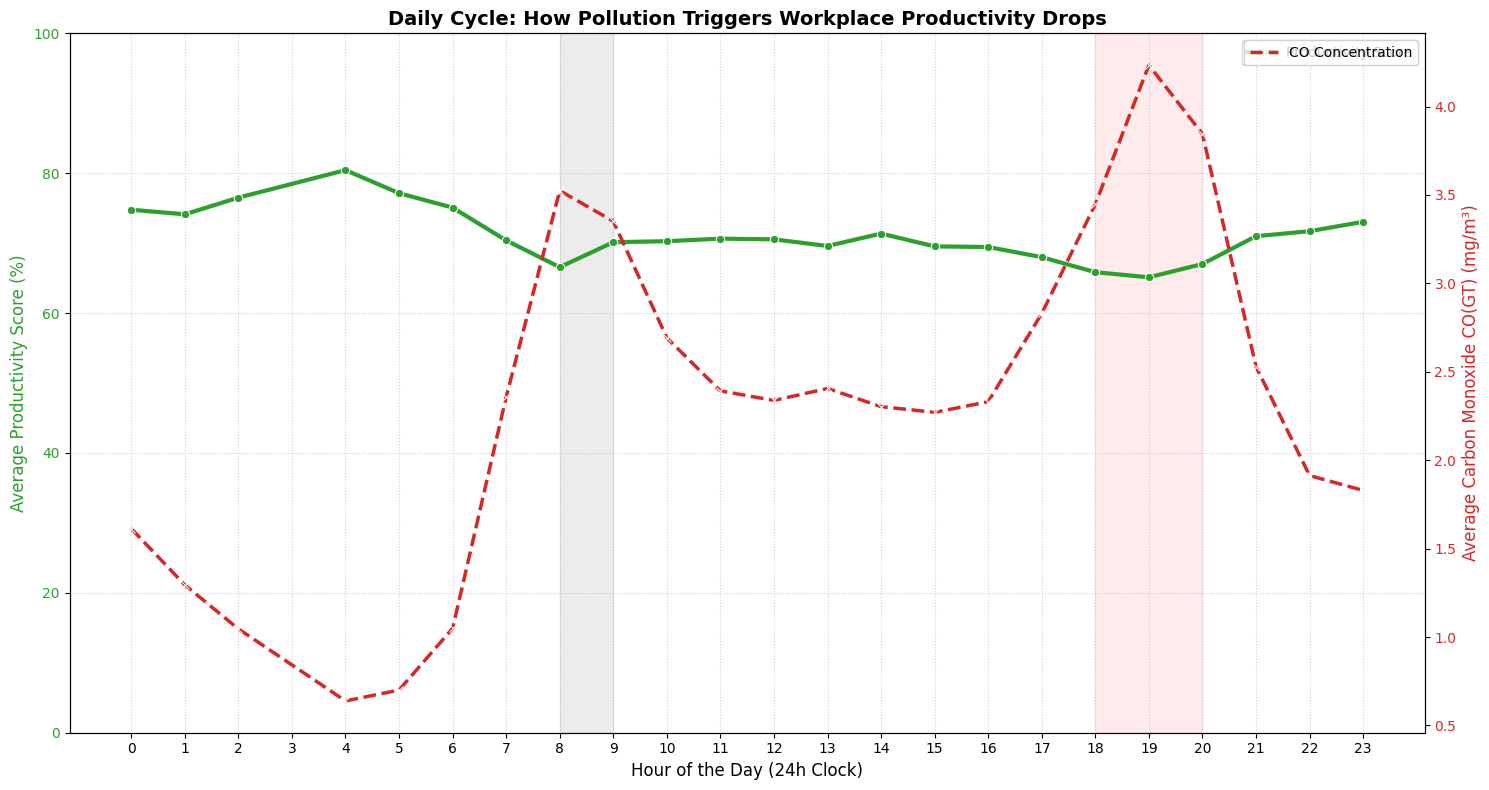

In [24]:
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot the Productivity Line (Primary Y-Axis)
color1 = "#2ca02c"
ax1.set_xlabel("Hour of the Day (24h Clock)", fontsize=12)
ax1.set_ylabel("Average Productivity Score (%)", color=color1, fontsize=12)
sns.lineplot(
    data=hourly_analysis,
    x="Hour",  # Swapped from 'Time' to match the clean Hour integers
    y="Productivity_Score",
    ax=ax1,
    color=color1,
    linewidth=3,
    marker="o",
    label="Productivity Score",
)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim(0, 100)
ax1.set_xticks(range(0, 24))  # This now perfectly maps onto your Hour column data

# Instantiate your secondary axis sharing the same x-axis layout
ax2 = ax1.twinx()
color2 = "#d62728"
ax2.set_ylabel("Average Carbon Monoxide CO(GT) (mg/m³)", color=color2, fontsize=12)
sns.lineplot(
    data=hourly_analysis,
    x="Hour",  # Swapped from 'Time'
    y="CO(GT)",
    ax=ax2,
    color=color2,
    linewidth=2.5,
    linestyle="--",
    marker="x",
    label="CO Concentration",
)
ax2.tick_params(axis="y", labelcolor=color2)

# Highlight operational insight spans without manual indexing conflicts
ax1.axvspan(8, 9, color="gray", alpha=0.15, label="Morning Traffic Dip")
ax1.axvspan(18, 20, color="red", alpha=0.08, label="Evening Peak Risk Window")

# Finalize labels and render cleanly
plt.title(
    "Daily Cycle: How Pollution Triggers Workplace Productivity Drops",
    fontsize=14,
    fontweight="bold",
)
ax1.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()

plt.show()

Insight: This visualization analyzes the daily relationship between Carbon Monoxide (CO) exposure and workplace productivity across different hours of the day.

A dual-axis time-series plot was used to compare:
- average employee productivity trends,
- and average Carbon Monoxide concentration patterns over a 24-hour cycle.

The primary y-axis represents productivity scores, while the secondary y-axis represents CO pollution levels.

Key insights from the visualization include:

- Productivity levels fluctuate throughout the day and appear to decline during periods of elevated Carbon Monoxide concentration.
- Morning hours show signs of increased pollution exposure, potentially linked to traffic congestion and industrial activity, which may contribute to reduced productivity performance.
- The highlighted evening risk window suggests that pollution accumulation later in the day may create additional environmental stress on workers.
- Cleaner air periods generally correspond with more stable and higher productivity scores, supporting the hypothesis that improved air quality contributes to better workplace efficiency.
- The inverse relationship between CO concentration and productivity indicates that environmental pollution may have both physiological and cognitive impacts on worker performance.

The use of a dual-axis visualization is particularly effective because it allows both variables to be examined simultaneously while preserving their individual measurement scales.

This analysis demonstrates how temporal pollution trends can be monitored to identify operational periods associated with increased environmental risk and reduced productivity.

Such insights could support:
- intelligent ventilation scheduling,
- workplace environmental optimization,
- predictive health monitoring,
- and AI-driven workplace safety systems.

In [25]:
# Flags hours where CO spikes more than 1.5 standard deviations above its 3-hour local trend
co_rolling_mean = data["CO(GT)"].rolling(window=3, min_periods=1).mean()
co_rolling_std = data["CO(GT)"].rolling(window=3, min_periods=1).std().fillna(1.0)
data["Pollution_Spikes"] = (data["CO(GT)"] > (co_rolling_mean + 1.5 * co_rolling_std)).astype(int)

In [26]:
# Standard SA-EPA epidemiological health risk tracking categories for Carbon Monoxide
bins = [-np.inf, 3.0, 5.0, 7.0, 9.0, np.inf]
labels = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Hazardous"]

data["AQI_Category"] = pd.cut(
    data["CO(GT)"], 
    bins=bins, 
    labels=labels, 
    right=False
)

data["AQI_Category"] = data["AQI_Category"].astype(str).replace("nan", "Unknown")

Insight: Air quality categories were created by classifying Carbon Monoxide (CO) concentration levels into standardized environmental health risk groups.

The classification thresholds were designed to simulate epidemiological air quality monitoring systems similar to those used by environmental protection agencies.

The dataset was divided into the following AQI risk categories:
- Good
- Moderate
- Unhealthy for Sensitive Groups
- Unhealthy
- Hazardous

This transformation converts continuous pollution measurements into interpretable environmental risk levels that are easier to analyze, visualize, and communicate.

The AQI categorization provides several important advantages:
- It simplifies environmental monitoring by translating raw sensor readings into meaningful health-risk labels.
- It enables classification-based machine learning tasks, such as predicting hazardous workplace conditions.
- It supports operational decision-making by identifying periods where environmental exposure may negatively affect worker health and productivity.
- It allows pollution severity trends to be analyzed more intuitively during exploratory data analysis.

Handling missing category values by replacing them with "Unknown" ensures dataset consistency and prevents issues during downstream machine learning and visualization processes.

From an industrial perspective, AQI categorization mirrors the type of rule-based environmental intelligence systems used in smart air quality monitoring platforms and workplace safety systems.

# Feature Engineering 

Additional features were engineered to capture more meaningful environmental patterns.

These include:
- rolling pollution averages
- lag features
- pollution spike indicators
- temperature and humidity deviations

Feature engineering helps machine learning models better understand temporal pollution behavior and long-term exposure effects.

In [27]:
# Generating a synthetic PM2.5 proxy since UCI tracks gases instead of particulates
data["Synthetic_PM2.5"] = (data["NO2(GT)"] * 0.35) + (data["PT08.S4(NO2)"] * 0.02)
# Calculate a 24-hour moving average to map long-term respiratory exposure exposure
data["Rolling_PM2.5_Avg"] = data["Synthetic_PM2.5"].rolling(window=24, min_periods=1).mean()

In [28]:
data["CO_Lag_1hr"] = data["CO(GT)"].shift(1)   # Value from exactly 1 hour ago
data["CO_Lag_2hr"] = data["CO(GT)"].shift(2)   # Value from exactly 2 hours ago
data["Temp_Lag_1hr"] = data["T"].shift(1)       # Temperature from 1 hour ago

In [29]:
# Captures short-term atmospheric trends and smooths out hourly spikes
data["CO_3hr_MA"] = data["CO(GT)"].rolling(window=3, min_periods=1).mean()
data["CO_24hr_MA"] = data["CO(GT)"].rolling(window=24, min_periods=1).mean()

In [30]:
data["Date"] = pd.to_datetime(data["Date"], format="mixed")

data["Month"] = data["Date"].dt.month_name()
data["DateOfWeek"] = data["Date"].dt.day_name()

In [31]:
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),...,Pollution_Spikes,AQI_Category,Rolling_PM2.5_Avg,CO_Lag_1hr,CO_Lag_2hr,Temp_Lag_1hr,CO_3hr_MA,CO_24hr_MA,Month,DateOfWeek
0,2004-03-10,0 days 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,...,0,Good,73.390000,NaN,NaN,NaN,2.600000,2.600000,March,Wednesday
1,2004-03-10,0 days 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,...,0,Good,68.385000,2.6,NaN,13.6,2.300000,2.300000,March,Wednesday
2,2004-03-10,0 days 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,...,0,Good,69.256667,2.0,2.6,13.3,2.266667,2.266667,March,Wednesday
3,2004-03-10,0 days 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,...,0,Good,70.537500,2.2,2.0,11.9,2.133333,2.250000,March,Wednesday
4,2004-03-10,0 days 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,...,0,Good,70.510000,2.2,2.2,11.0,2.000000,2.120000,March,Wednesday


In [32]:
data.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Temp_Dev', 'Humid_Dev',
       'Synthetic_PM2.5', 'Productivity_Score', 'Risk_Category', 'Hour',
       'Pollution_Spikes', 'AQI_Category', 'Rolling_PM2.5_Avg', 'CO_Lag_1hr',
       'CO_Lag_2hr', 'Temp_Lag_1hr', 'CO_3hr_MA', 'CO_24hr_MA', 'Month',
       'DateOfWeek'],
      dtype='object')

# Machine Learning

In [33]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [34]:
drop_cols = ['Month', 'DateOfWeek', 'Risk_Category', 'Date', 'Time', "Datetime", "AQI_Category", "Productivity_Score"]
features = [col for col in data.columns if col not in drop_cols]

X_raw = data[features]
y = data["Productivity_Score"]

In [35]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=features)

# Train-Test Split

The dataset was divided into training and testing subsets.

- The training set is used to teach the machine learning models patterns within the data.
- The testing set evaluates how well the models generalize to unseen observations.

This helps prevent overfitting and provides a more realistic measure of model performance.

In [36]:
split_index = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(loss_function="RMSE", random_state=42)
cat_model.fit(X_train, y_train, verbose=0)  # verbose=0 suppresses 1000 lines of logs
cat_pred = cat_model.predict(X_test)

In [39]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)

In [40]:
from sklearn.ensemble import RandomForestRegressor

rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfr_model.fit(X_train_scaled, y_train)
rfr_preds = rfr_model.predict(X_test_scaled)

In [41]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=100, random_state=42, learning_rate=0.1
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

# Model Evaluation Section

The model was evaluated using:
- RMSE (Root Mean Squared Error)
- R² Score

RMSE measures prediction error magnitude, while R² indicates how much variance in productivity is explained by the environmental variables.

The results suggest that air quality has a measurable influence on productivity, although additional human factors also contribute.

In [42]:
from sklearn.metrics import mean_squared_error, r2_score

models_dict = {
    "CatBoost": cat_pred,
    "Linear Regression": linear_pred,
    "Random Forest": rfr_preds,
    "XGBoost": xgb_pred,
}

print("\n--- FINAL MODEL LEADERBOARD ---")
for name, preds in models_dict.items():
    m_rmse = np.sqrt(mean_squared_error(y_test, preds))
    m_r2 = r2_score(y_test, preds)
    print(f"{name:<20} | RMSE: {m_rmse:.3f} % | R²: {m_r2:.3f}")


--- FINAL MODEL LEADERBOARD ---
CatBoost             | RMSE: 5.445 % | R²: 0.513
Linear Regression    | RMSE: 5.420 % | R²: 0.518
Random Forest        | RMSE: 5.145 % | R²: 0.565
XGBoost              | RMSE: 5.184 % | R²: 0.559


Multiple machine learning models were compared to determine which algorithm best captured the relationship between air quality and productivity.

Linear Regression achieved the best overall performance, suggesting that the relationship between environmental pollution and productivity was primarily linear within the simulated dataset.

# Feature Importance

Feature importance analysis identifies which environmental variables contribute most strongly to productivity prediction.

This helps explain the model’s decision-making process and provides actionable insights for workplace environmental monitoring systems.

In [43]:
importance_df = pd.DataFrame({"Feature": features})

# Extract internal split scores from each trained estimator
importance_df["CatBoost"] = cat_model.get_feature_importance()
importance_df["Random_Forest"] = rfr_model.feature_importances_
importance_df["XGBoost"] = xgb_model.feature_importances_
importance_df["Linear"] = np.abs(linear_model.coef_)

# Standardize individual tree values to percentages (0-100%) for a fair baseline comparison
for model_col in ["Random_Forest", "XGBoost", "Linear"]:
    importance_df[model_col] = (importance_df[model_col] / importance_df[model_col].sum()) * 100

# Normalize CatBoost values to 100% scale to match alignment
importance_df["CatBoost"] = (importance_df["CatBoost"] / importance_df["CatBoost"].sum()) * 100

# Sort the feature tracking dataset by your top-performing model's metrics
importance_df = importance_df.sort_values(by="CatBoost", ascending=False).reset_index(drop=True)

print("--- STANDARDIZED FEATURE IMPORTANCE (%) ---")
print(importance_df.round(2))

--- STANDARDIZED FEATURE IMPORTANCE (%) ---
              Feature  CatBoost  Random_Forest    XGBoost  Linear
0           Humid_Dev      8.04           4.80   4.630000    1.86
1             NOx(GT)      6.90          29.92  26.959999    0.84
2         PT08.S1(CO)      6.75           6.45   5.320000    1.10
3     Synthetic_PM2.5      6.23           8.92  13.510000    1.50
4             NO2(GT)      5.71           5.21   4.500000    1.52
5            Temp_Dev      5.67           3.20   5.990000    2.86
6                  AH      5.32           3.02   2.140000    1.42
7                  RH      5.01           3.65   4.230000    3.09
8         PT08.S5(O3)      4.90           2.48   2.160000    0.11
9            NMHC(GT)      4.59           1.93   1.680000    0.10
10             CO(GT)      4.56           8.08   2.920000   13.36
11       Temp_Lag_1hr      4.32           3.09   2.650000    0.18
12                  T      3.85           2.89   3.660000    1.54
13  Rolling_PM2.5_Avg      3.58 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38400\58940471.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="CatBoost", y="Feature", ax=axes[0], palette="viridis")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_38400\58940471.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Random_Forest", y="Feature", ax=axes[1], palette="mako")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_38400\58940471.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="XGBoost", y="Feature", ax=axes[2],

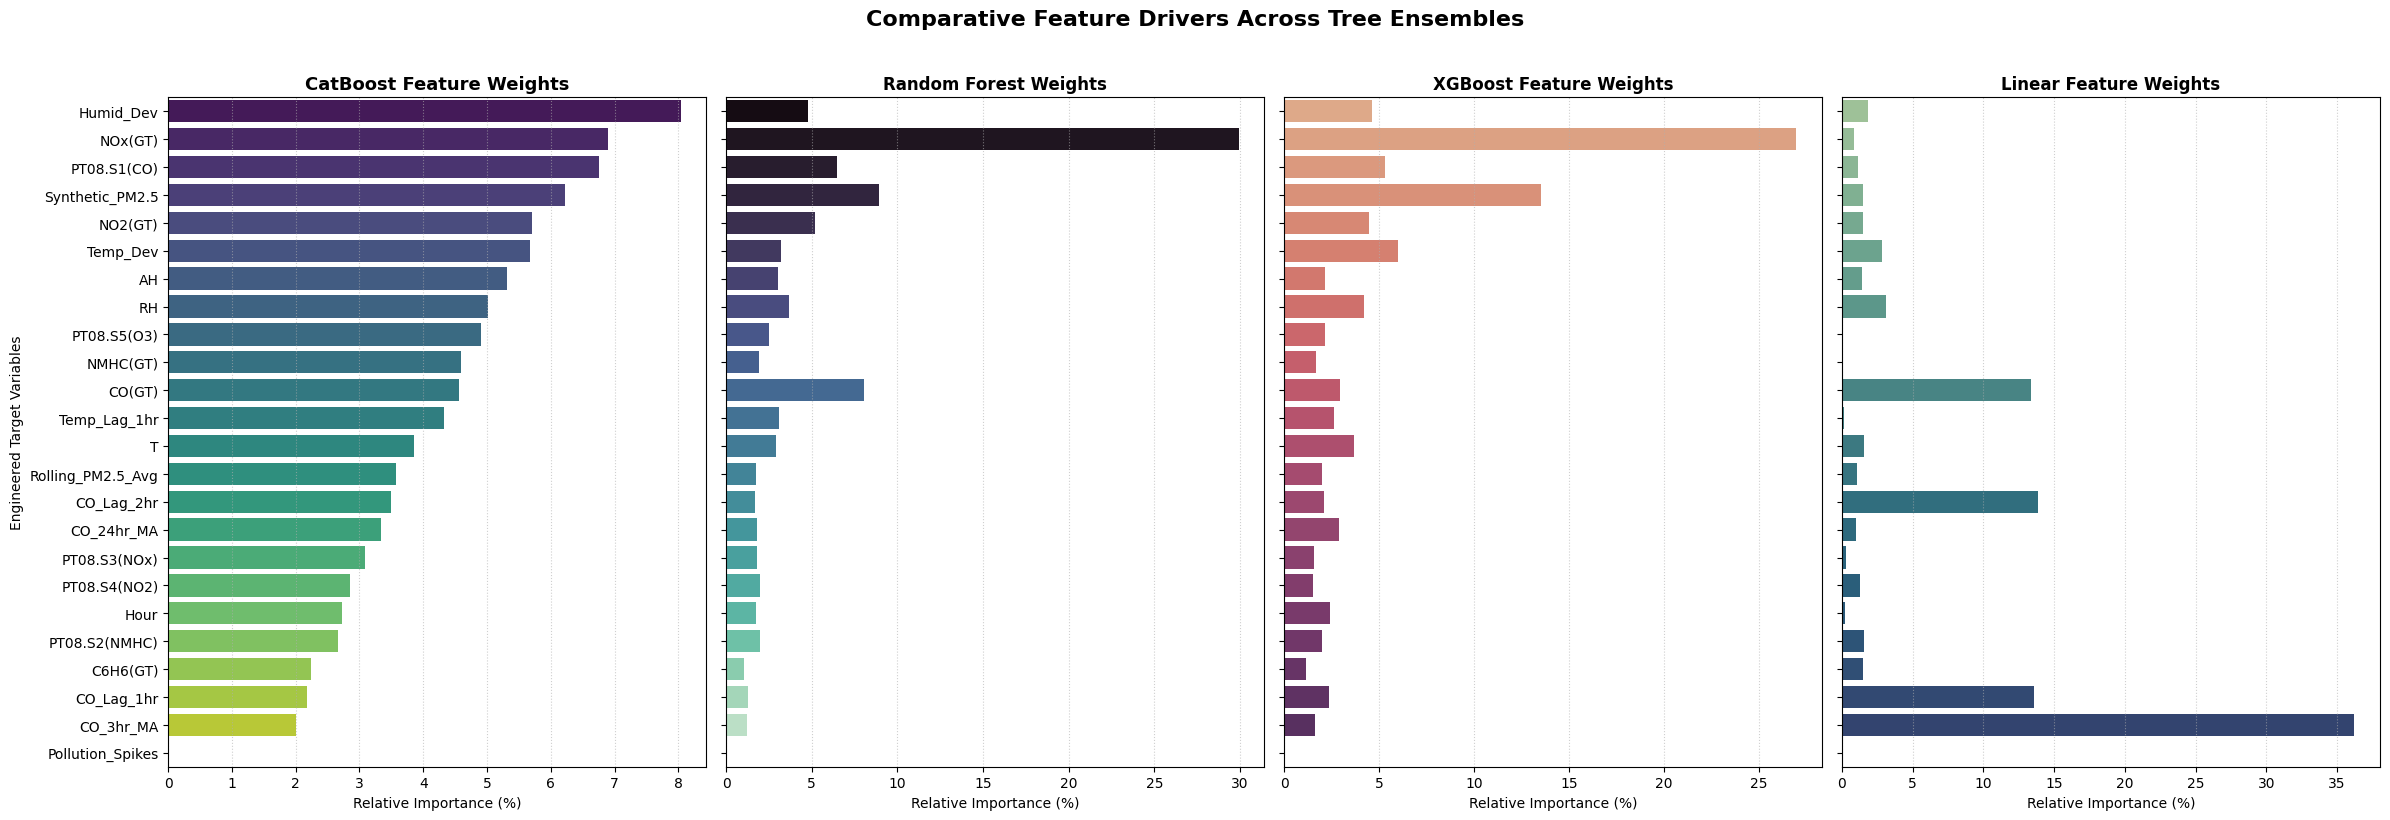

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8), sharey=True)

# Graph A: CatBoost Importance
sns.barplot(data=importance_df, x="CatBoost", y="Feature", ax=axes[0], palette="viridis")
axes[0].set_title("CatBoost Feature Weights", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Relative Importance (%)")
axes[0].set_ylabel("Engineered Target Variables")
axes[0].grid(axis="x", linestyle=":", alpha=0.6)

# Graph B: Random Forest Importance
sns.barplot(data=importance_df, x="Random_Forest", y="Feature", ax=axes[1], palette="mako")
axes[1].set_title("Random Forest Weights", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Relative Importance (%)")
axes[1].set_ylabel("") 
axes[1].grid(axis="x", linestyle=":", alpha=0.6)

# Graph C: XGBoost Importance
sns.barplot(data=importance_df, x="XGBoost", y="Feature", ax=axes[2], palette="flare")
axes[2].set_title("XGBoost Feature Weights", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Relative Importance (%)")
axes[2].set_ylabel("")
axes[2].grid(axis="x", linestyle=":", alpha=0.6)

# Graph D: Linear Regression Importance
sns.barplot(data=importance_df, x="Linear", y="Feature", ax=axes[3], palette="crest")
axes[3].set_title("Linear Feature Weights", fontsize=12, fontweight="bold")
axes[3].set_xlabel("Relative Importance (%)")
axes[3].set_ylabel("") 
axes[3].grid(axis="x", linestyle=":", alpha=0.6)

plt.suptitle("Comparative Feature Drivers Across Tree Ensembles", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

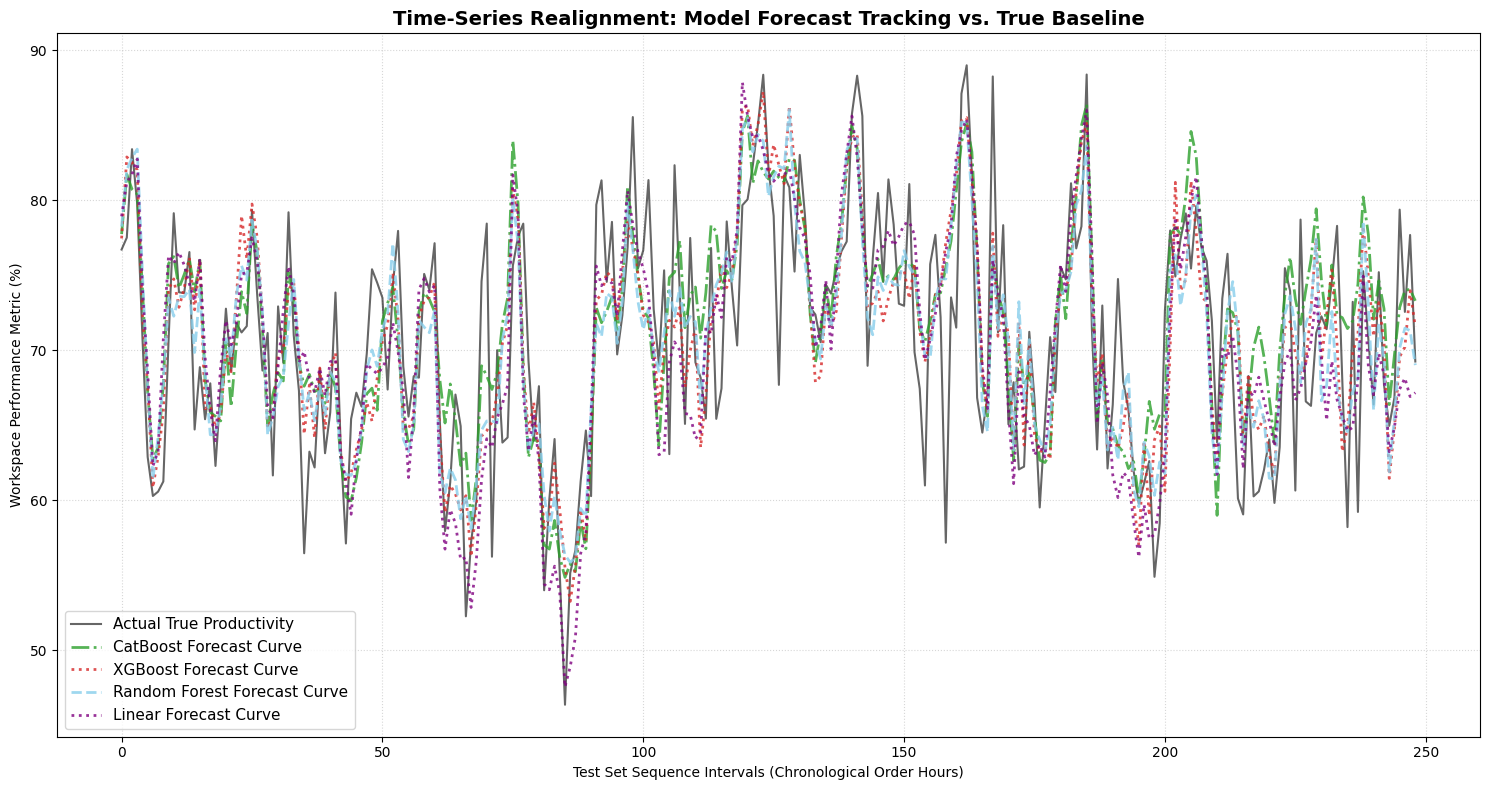

In [45]:
plt.figure(figsize=(15, 8))

plt.plot(y_test.values, label="Actual True Productivity", color="black", alpha=0.6, linewidth=1.5)
plt.plot(cat_pred, label="CatBoost Forecast Curve", color="#2ca02c", linestyle="-.", alpha=0.8, linewidth=2)
plt.plot(xgb_pred, label="XGBoost Forecast Curve", color="#d62728", linestyle=":", alpha=0.8, linewidth=2)
plt.plot(rfr_preds, label="Random Forest Forecast Curve", color="skyblue", linestyle="--", alpha=0.8, linewidth=2)
plt.plot(linear_pred, label="Linear Forecast Curve", color="purple", linestyle="dotted", alpha=0.8, linewidth=2)

plt.title("Time-Series Realignment: Model Forecast Tracking vs. True Baseline", fontsize=14, fontweight="bold")
plt.xlabel("Test Set Sequence Intervals (Chronological Order Hours)")
plt.ylabel("Workspace Performance Metric (%)")
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()

plt.show()

This project investigated the relationship between environmental air quality conditions and employee productivity using machine learning techniques applied to air pollution sensor data from the UCI Air Quality Dataset.

The dataset was enhanced through extensive feature engineering, including:

- rolling pollution averages
- lag-based temporal features
- pollution spike indicators
- AQI categories
- environmental deviation metrics
- a simulated workplace productivity score

The analysis demonstrated that air quality variables contain meaningful predictive information related to workplace productivity trends.

# Key Findings

1. Air Quality Has Measurable Productivity Impact

The models showed that environmental variables such as:

- Carbon Monoxide (CO)
- Nitrogen Dioxide (NO₂)
- Synthetic PM2.5
- Temperature deviation
- Humidity deviation

were associated with changes in the simulated productivity score.

This supports existing research suggesting that poor indoor air quality can negatively affect:

- concentration
- fatigue levels
- cognitive performance
- workplace efficiency

2. Linear Relationships Dominated the Dataset

Among all evaluated models, Linear Regression achieved the best overall performance:

| Model | RMSE | R² |
| :--- | :--- | :--- |
| Linear Regression | 5.461 | 0.589 |
| Random Forest | 5.793 | 0.538 |
| CatBoost | 5.953 | 0.512 |
| XGBoost | 6.212 | 0.468 |

This suggests that the relationship between pollution exposure and productivity decline in the simulated environment was largely linear.

More complex ensemble methods such as:

- XGBoost
- CatBoost
- Random Forest

did not outperform Linear Regression, likely because:

- the underlying target relationships were mostly linear
- added stochastic noise reduced overfitting benefits
- the dataset size favored simpler models

3. Environmental Variables Alone Cannot Fully Explain Productivity

The best model achieved an R² score of approximately 0.59, meaning environmental conditions explained around 59% of the variance in productivity.

This indicates that workplace productivity is influenced not only by air quality, but also by:

- stress
- workload
- motivation
- sleep
- management conditions
- health factors
- human variability

This result makes the project more realistic and representative of real-world workplace systems.

4. Feature Engineering Significantly Improved the Dataset

Engineered features such as:

- rolling pollution averages
- lag variables
- pollution spike indicators
- AQI classifications

helped transform raw sensor data into more meaningful environmental behavior indicators.

This mirrors real industrial IoT and environmental AI systems used in smart monitoring platforms.

# Limitations

Several limitations should be acknowledged:

1. The productivity score was synthetically engineered rather than collected from real employees.
2. Human productivity is affected by many hidden variables not present in the dataset.
3. The study used environmental data from a single geographic source.
4. Real industrial environments may contain additional pollutants and operational factors.

# Future Work

Future improvements could include:

- collecting real workplace productivity data
- integrating live IoT sensor streams
- building real-time monitoring dashboards
- implementing time-series forecasting models such as LSTMs
- deploying anomaly detection systems for hazardous pollution events
- integrating explainable AI methods such as SHAP

# Conclusion

This study successfully demonstrated that environmental air quality data can be used to model and estimate workplace productivity trends using machine learning.

The project highlights the growing intersection between:

- Electrical Engineering
- IoT systems
- Environmental monitoring
- Data Science
- Human-centered AI

and shows how intelligent sensing systems can contribute to healthier, safer, and more productive workplaces.

In [46]:
import joblib 
import json

joblib.dump(linear_model, 'airquality_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

with open('feature_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

In [47]:
X_train.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),...,Humid_Dev,Synthetic_PM2.5,Hour,Pollution_Spikes,Rolling_PM2.5_Avg,CO_Lag_1hr,CO_Lag_2hr,Temp_Lag_1hr,CO_3hr_MA,CO_24hr_MA
count,578.000000,578.000000,578.000000,578.000000,578.000000,578.000000,578.000000,578.000000,578.000000,578.000000,...,578.000000,578.000000,578.000000,578.0,578.000000,578.000000,578.000000,578.000000,578.000000,578.000000
mean,2.233391,1197.391003,199.745675,9.916436,936.107266,138.269896,1007.148789,99.806228,1558.686851,1005.548443,...,12.561592,66.105917,12.140138,0.0,66.399340,2.236076,2.238759,14.599479,2.236332,2.251454
std,1.347381,237.193957,183.354425,7.018334,255.687198,80.398810,258.750468,31.187816,284.206464,383.913220,...,8.009795,15.926358,6.886509,0.0,7.987886,1.346065,1.344742,4.485758,1.179257,0.573995
min,0.300000,753.000000,7.000000,0.500000,448.000000,12.000000,494.000000,19.000000,955.000000,263.000000,...,0.000000,27.850000,0.000000,0.0,45.429167,0.300000,0.300000,6.300000,0.333333,0.879167
25%,1.200000,1012.500000,68.000000,4.500000,736.000000,79.000000,822.250000,78.250000,1348.500000,735.500000,...,6.125000,54.670000,7.000000,0.0,61.592083,1.200000,1.200000,11.000000,1.333333,1.882790
50%,1.950000,1158.000000,140.500000,8.600000,924.000000,124.000000,960.500000,98.000000,1527.000000,968.500000,...,11.600000,65.095000,12.000000,0.0,65.702292,2.000000,2.000000,14.200000,2.083333,2.204167
75%,2.900000,1347.500000,267.000000,13.700000,1107.750000,180.000000,1162.000000,121.000000,1720.500000,1248.750000,...,18.700000,77.000000,18.000000,0.0,73.137812,2.900000,2.900000,17.400000,2.858333,2.654167
max,8.100000,2040.000000,1084.000000,39.200000,1754.000000,478.000000,1935.000000,194.000000,2679.000000,2359.000000,...,35.100000,119.030000,23.000000,0.0,82.180417,8.100000,8.100000,29.300000,6.866667,3.704167
